# Data Augmentation for Image Classification

## Cat vs Dog Classification

Data augmentation is a technique used to artificially increase the variety of training images by applying random transformations to existing images.

Instead of collecting new images, we create slightly modified versions of the existing training images.

Common transformations include:

- Horizontal flipping
- Rotation
- Zooming
- Translation
- Contrast changes

The goal is to help the model generalize better and reduce overfitting.

## Why Do We Need Data Augmentation?

Deep learning models usually perform better when they have more diverse training data.

When the dataset is small, the model can memorize the training images instead of learning general patterns.

This is called **overfitting**.

For example, if the model sees a cat only from one particular angle, it may struggle when it sees the same type of cat from another angle.

Data augmentation creates variations of the original images so that the model learns more robust visual features.

### Example

Original image:

Cat sitting normally

↓

Augmented images:

- Horizontally flipped cat
- Slightly rotated cat
- Zoomed cat
- Cat with different contrast

## Important Concept

Data augmentation should normally be applied to the **training data**.

We do not randomly augment validation and test data because those datasets should represent the original unseen data used to measure the model's real performance.

Therefore:

Training Data → Augmentation ✅

Validation Data → No augmentation ❌

Test Data → No augmentation ❌

In [3]:
from pathlib import Path
import tensorflow as tf

DATA_DIR = Path(r"F:\Anas\Dataset\PetImages_100")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="training"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
    validation_split=0.2,
    subset="validation"
)

class_names = train_dataset.class_names

print("Classes:", class_names)

Found 100 files belonging to 2 classes.
Using 80 files for training.
Found 100 files belonging to 2 classes.
Using 20 files for validation.
Classes: ['Cat', 'Dog']


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Creating Data Augmentation Layers

TensorFlow/Keras provides preprocessing layers that can perform random transformations on images.

We will use:

1. RandomFlip
2. RandomRotation
3. RandomZoom
4. RandomContrast

These transformations are applied randomly during training.

In [2]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


## Understanding the Augmentation Techniques

### 1. RandomFlip

Randomly flips an image horizontally.

Example:

Left-facing cat → Right-facing cat

This teaches the model that the object is still a cat even when its orientation changes.

### 2. RandomRotation

Randomly rotates the image by a small amount.

This helps the model recognize objects from slightly different angles.

### 3. RandomZoom

Randomly zooms into or out of the image.

This helps the model learn objects at different scales.

### 4. RandomContrast

Randomly changes image contrast.

This helps the model become less dependent on a specific lighting condition.

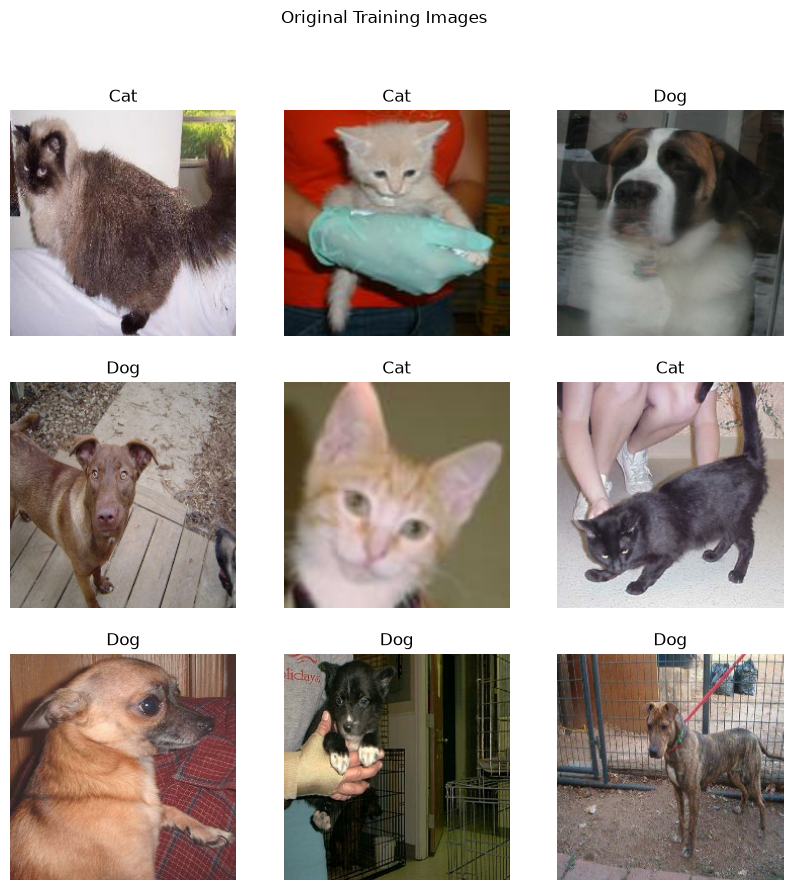

In [4]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Original Training Images")
plt.show()

## Visualizing Augmented Images

The following code applies our augmentation pipeline to the same images multiple times.

Because the transformations are random, the generated images can look different each time.

This demonstrates how one original image can produce many different training examples.

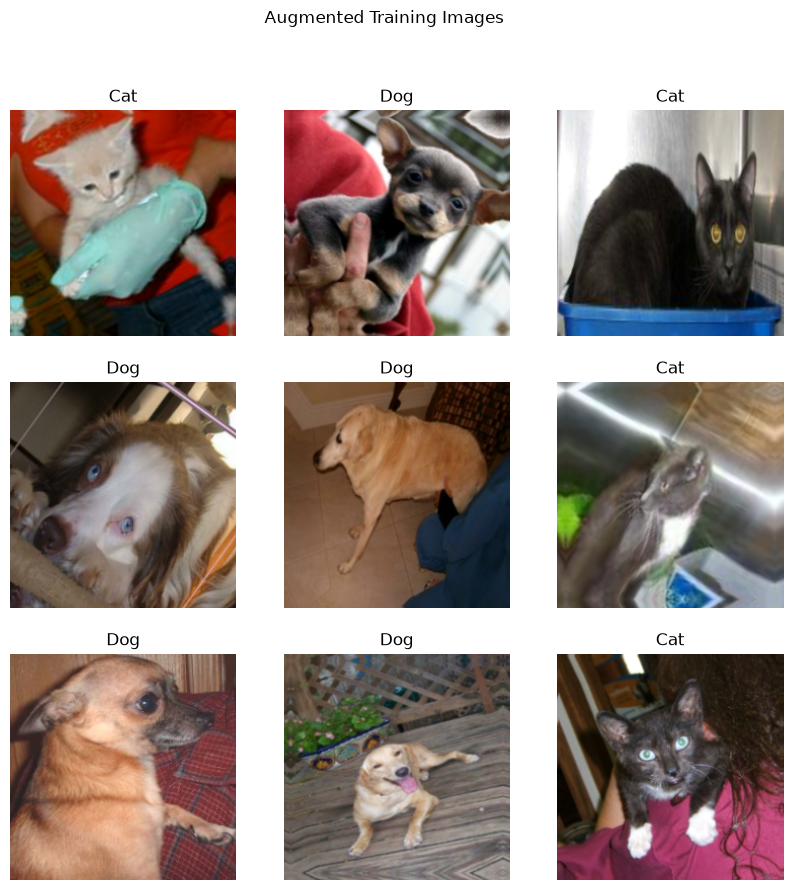

In [5]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            augmented_images[i].numpy().astype("uint8")
        )

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Augmented Training Images")
plt.show()

## Observation

Notice that the class label does not change after augmentation.

For example:

Cat → Flipped Cat → Still Cat

Dog → Rotated Dog → Still Dog

The image changes, but its label remains the same.

This is an important requirement of image data augmentation.

We should only apply transformations that preserve the original class.